### Importar bibliotecas

In [20]:
import os
import sys
import datetime
import pandas as pd
import gc #limpar cache
import matplotlib.pyplot as plt

sys.path.append("/mnt/storage_C4/gaussian_football")
sys.path.append("/mnt/storage_C4/gaussian_football/preprocessing")
sys.path.append("/mnt/storage_C4/gaussian_football/models/nn")

import random
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
import torchvision
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter
from models.nn.cnnbilstm import CNNBiLSTM
from models.nn.resnet_audio import ResNetLSTM_MEL
#from models.nn.resnetlstm import ResNetLSTM50
from preprocessing.loaders import build_mel_dataloader, build_video_dataloader
from preprocessing.balanced_dataset import balanced_df

In [2]:
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)
print(f"CUDA disponível: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Versão do CUDA: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

seed = 435
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Semente: {seed}")
print(f"Dispositivo: {device}")

Versão do Torch: 2.5.1+cu121
Versão do Torchvision: 0.20.1+cu121
CUDA disponível: True
Versão do CUDA: 12.1
GPU: NVIDIA RTX A4500
Semente: 435
Dispositivo: cuda


### Importar os dados e criar dasaset balanceado para o mel spectrograma

In [3]:
# balanceando os dados

all_data = pd.read_csv("/mnt/storage_C4/gaussian_football/data/labels/labels_all.csv")

all_train = all_data[all_data['split'] == 'train'] # todos os dados do conjunto de treino
all_valid = all_data[all_data['split'] == 'valid']
all_test = all_data[all_data['split'] == 'test']

balanced_train = balanced_df(all_train, 'game_id', threshold=0.5, random_state=seed)
balanced_valid = balanced_df(all_valid, 'game_id', threshold=0.5, random_state=seed)
balanced_test = balanced_df(all_test, 'game_id', threshold=0.5, random_state=seed)

# salvar em csv
balanced_train.to_csv('/mnt/storage_C4/gaussian_football/data/labels/balanced_labels_train.csv', index=False)
balanced_valid.to_csv('/mnt/storage_C4/gaussian_football/data/labels/balanced_labels_val.csv', index=False)
balanced_test.to_csv('/mnt/storage_C4/gaussian_football/data/labels/balanced_labels_test.csv', index=False)

In [4]:
TRAIN_PATH = '/mnt/storage_C4/gaussian_football/data/labels/balanced_labels_train.csv'
VAL_PATH = '/mnt/storage_C4/gaussian_football/data/labels/balanced_labels_val.csv'

train_mel_loader_balanced = build_mel_dataloader(
    csv_path=TRAIN_PATH,
    split="train",
    batch_size=2,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    target_shape=(128, 256)
)

valid_mel_loader_balanced = build_mel_dataloader(
    csv_path=VAL_PATH,
    split="valid",
    batch_size=2,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    target_shape=(128, 256)
)

Dataset: 1467/1514 exemplos válidos.
Dataset: 579/654 exemplos válidos.


O shape padrão dos mel spectogramas é (128, 256) definido em loaders

### Avaliação

A avaliação vai ser feita utilizando o CCC (Coeficiente de Correlação de Concordância):

In [5]:
def calculate_ccc(y_true, y_pred):
    """Calcula o Concordance Correlation Coefficient (CCC)."""
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)

    covariance = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    numerator = 2 * covariance
    denominator = var_true + var_pred + (mean_true - mean_pred) ** 2

    return 0.0 if denominator == 0 else numerator / denominator

### Treinamento

In [6]:
def train_model_audio(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler,
    epochs=10,
    device="cuda",
    patience=5,
    checkpoint_path="best_model.pth",
    nome_modelo='ESQUECEU_O_NOME'
):
    """
    Treina a rede e a avalia a cada época usando o CCC como métrica principal.

    Argumentos:
        model:            Modelo PyTorch.
        train_loader:     DataLoader para os dados de treino.
        val_loader:       DataLoader para os dados de validação.
        optimizer:        Otimizador (ex: AdamW).
        criterion:        Função de perda (ex: nn.MSELoss()).
        scheduler:        Scheduler de learning rate (ex: ReduceLROnPlateau).
        epochs:           Número máximo de épocas.
        device:           Dispositivo de treino ("cuda" ou "cpu").
        patience:         Épocas sem melhora no CCC antes de acionar early stopping.
        checkpoint_path:  Caminho para salvar o melhor modelo.
    """

    assert nome_modelo != 'ESQUECEU_O_NOME', "Coloque um nome nesse modelo, por favor"

    model.to(device)
    best_val_ccc = -1.0 # CCC varia de - 1 a 1, quanto mais perto de 1, melhor
    epochs_no_improve = 0

    current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    log_dir = os.path.join("runs", f"arousal_{current_time}")
    writer = SummaryWriter(log_dir=log_dir)
    print(f"TensorBoard: {log_dir}")

    for epoch in range(epochs):

        # ------------------------------------------------------------------ #
        # TREINO
        # ------------------------------------------------------------------ #
        model.train()
        train_loss = 0.0

        for mel_tensor, targets in tqdm(
            train_loader, desc=f"Época {epoch+1}/{epochs} [treino]"
        ):
            mel_spcs = mel_tensor.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(mel_spcs).squeeze(1)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * mel_spcs.size(0)

        train_loss /= len(train_loader.dataset)

        # ------------------------------------------------------------------ #
        # VALIDAÇÃO
        # ------------------------------------------------------------------ #
        model.eval()
        val_loss = 0.0
        all_true = []
        all_pred = []

        with torch.no_grad():
            for mel_tensor, targets in tqdm(
                val_loader, desc=f"Época {epoch+1}/{epochs} [val]"
            ):
                mel_spcs = mel_tensor.to(device)
                targets = targets.to(device)

                outputs = model(mel_spcs).squeeze(1)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * mel_spcs.size(0)

                all_true.extend(targets.cpu().numpy())
                all_pred.extend(outputs.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_mae = np.mean(np.abs(np.array(all_true) - np.array(all_pred)))
        val_ccc = calculate_ccc(np.array(all_true), np.array(all_pred))

        scheduler.step(val_loss)

        # ------------------------------------------------------------------ #
        # TENSORBOARD
        # ------------------------------------------------------------------ #
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
        writer.add_scalar("Metrics/MAE", val_mae, epoch)
        writer.add_scalar("Metrics/CCC", val_ccc, epoch)
        writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)

        print(
            f"Época [{epoch+1}/{epochs}]"
            f" | Train Loss: {train_loss:.4f}"
            f" | Val Loss: {val_loss:.4f}"
            f" | Val MAE: {val_mae:.4f}"
            f" | Val CCC: {val_ccc:.4f}"
            f" | LR: {optimizer.param_groups[0]['lr']:.2e}"
        )

        # ------------------------------------------------------------------ #
        # CHECKPOINT + EARLY STOPPING
        # ------------------------------------------------------------------ #
        if val_ccc > best_val_ccc:
            best_val_ccc = val_ccc
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_ccc": best_val_ccc,
            }, checkpoint_path)
            print(f"Novo melhor modelo salvo! (CCC: {best_val_ccc:.4f})")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"Sem melhora por {epochs_no_improve}/{patience} épocas.")
            if epochs_no_improve >= patience:
                print("Early stopping ativado.")
                break

    writer.close()
    print(f"\nTreinamento concluído. Melhor CCC: {best_val_ccc:.4f}")

Resnet para mel (sem lstm):

In [7]:
from torchvision.models import resnet18, ResNet18_Weights

class ResNet18_Mel(nn.Module):
    def __init__(self, dropout_p=0.3):
        super().__init__()

        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)

        # adapta primeira convolução para 1 canal
        old_weight = backbone.conv1.weight

        new_conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        with torch.no_grad():
            new_conv.weight[:] = old_weight.mean(dim=1, keepdim=True)

        backbone.conv1 = new_conv

        # remove a classificação
        self.features = nn.Sequential(*list(backbone.children())[:-1])

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (B,1,128,256)

        x = self.features(x)
        x = self.regressor(x)

        return x

In [8]:
model_rn_mel = ResNet18_Mel(
    dropout_p=0.3
).to(device)

criterion = nn.MSELoss()
optimizer = AdamW(model_rn_mel.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5, verbose=True)

print(f"Parâmetros treináveis: {sum(p.numel() for p in model_rn_mel.parameters() if p.requires_grad):,}")

train_model_audio(
    model=model_rn_mel,
    train_loader=train_mel_loader_balanced,
    val_loader=valid_mel_loader_balanced,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    epochs=30,
    device=device,
    patience=30,
    checkpoint_path="/mnt/storage_C4/gaussian_football/models/checkpoints/resnet18_audio.pth",
    nome_modelo='RESNET_AUDIO_1A_TENTATIVA'
)

/mnt/storage_C4/gaussian_football/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Parâmetros treináveis: 11,318,081
TensorBoard: runs/arousal_20260612-114227


Época 1/30 [val]: 100%|██████████| 290/290 [00:00<00:00, 322.81it/s]


Época [1/30] | Train Loss: 0.1980 | Val Loss: 0.3984 | Val MAE: 0.4628 | Val CCC: 0.4437 | LR: 1.00e-04
Novo melhor modelo salvo! (CCC: 0.4437)


Época 2/30 [val]: 100%|██████████| 290/290 [00:01<00:00, 270.71it/s]


...

Época [28/30] | Train Loss: 0.0129 | Val Loss: 14.0733 | Val MAE: 1.4958 | Val CCC: 0.0978 | LR: 1.56e-06
Sem melhora por 27/30 épocas.


Época 29/30 [val]: 100%|██████████| 290/290 [00:00<00:00, 469.75it/s]


Época [29/30] | Train Loss: 0.0133 | Val Loss: 13.9064 | Val MAE: 1.4808 | Val CCC: 0.0979 | LR: 7.81e-07
Sem melhora por 28/30 épocas.


Época 30/30 [val]: 100%|██████████| 290/290 [00:00<00:00, 325.00it/s]

Época [30/30] | Train Loss: 0.0136 | Val Loss: 5.3154 | Val MAE: 0.9376 | Val CCC: 0.1517 | LR: 7.81e-07
Sem melhora por 29/30 épocas.

Treinamento concluído. Melhor CCC: 0.4437


Treinamento com fine tuning:

In [17]:
def train_model_fine_tuning_audio(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler,
    epochs=10,
    device="cuda",
    patience=5,
    checkpoint_path="best_model.pth",
    unfreeze_epoch=3,
    nome_modelo='ESQUECEU_O_NOME'
):
    """
    Treina a rede e a avalia a cada época usando o CCC como métrica principal.
    Congela a ResNet inicial até atingir a 'unfreeze_epoch'.
    """

    assert nome_modelo != 'ESQUECEU_O_NOME', "Erro: Coloque um nome nesse modelo, por favor"

    assert not os.path.exists(checkpoint_path), f"Erro: O arquivo de checkpoint '{checkpoint_path}' já existe. Mude o nome para não sobrescrever."

    model.to(device)
    best_val_ccc = -1.0 
    epochs_no_improve = 0

    current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    log_dir = os.path.join("runs", f"arousal_{nome_modelo}_{current_time}")
    writer = SummaryWriter(log_dir=log_dir)
    print(f"TensorBoard: {log_dir}")

    # ================================================================== #
    # CONFIGURAÇÃO INICIAL: CONGELAR Aoutputs, targets RESNET
    # ================================================================== #
    # Congela toda a ResNet, EXCETO a primeira camada de 1 canal que você alterou
    print("=> Configuração Inicial: Congelando os pesos da ResNet (exceto a primeira camada)...")
    for name, param in model.features.named_parameters():
        if "0.weight" not in name:  # Mantém a primeira camada aberta pois ela foi reinicializada do zero
            param.requires_grad = False
            
    # Força o otimizador a olhar apenas para os parâmetros que estão ativos no momento
    # (Evita que o otimizador gaste memória/etapas com gradientes congelados)
    optimizer.param_groups[0]['params'] = [p for p in model.parameters() if p.requires_grad]

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "val_mae": [],
        "val_ccc": [],
        "lr": [],
    }

    for epoch in range(epochs):

        # ================================================================== #
        # LÓGICA DE DESCONGELAMENTO (UNFREEZE) CORRIGIDA
        # ================================================================== #
        if epoch == unfreeze_epoch:
            print(f"\n[ÉPOCA {epoch+1}] => ATENÇÃO: Descongelando os pesos da ResNet para Fine-Tuning completo!")
            
            # 1. Ativa o gradiente para absolutamente todos os parâmetros do modelo
            for param in model.parameters():
                param.requires_grad = True
                
            # 2. Captura a Learning Rate atualizada pelo scheduler antes de resetar
            current_lr = optimizer.param_groups[0]['lr']
            
            # 3. Recria o otimizador passando todos os parâmetros e preservando a LR e tipo de otimizador
            # (Exemplo assumindo que você usa AdamW, ajuste para o seu otimizador se for Adam ou SGD)
            optimizer = type(optimizer)(model.parameters(), lr=current_lr, weight_decay=optimizer.param_groups[0].get('weight_decay', 0))

        # ------------------------------------------------------------------ #
        # TREINO
        # ------------------------------------------------------------------ #
        model.train()
        train_loss = 0.0

        for mel_tensor, targets in tqdm(
            train_loader, desc=f"Época {epoch+1}/{epochs} [treino]"
        ):
            mel_spcs = mel_tensor.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(mel_spcs).squeeze(1)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * mel_spcs.size(0)

        train_loss /= len(train_loader.dataset)

        # ------------------------------------------------------------------ #
        # VALIDAÇÃO
        # ------------------------------------------------------------------ #
        model.eval()
        val_loss = 0.0
        all_true = []
        all_pred = []

        with torch.no_grad():
            for mel_tensor, targets in tqdm(
                val_loader, desc=f"Época {epoch+1}/{epochs} [val]"
            ):
                mel_spcs = mel_tensor.to(device)
                targets = targets.to(device)

                outputs = model(mel_spcs).squeeze(1)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * mel_spcs.size(0)

                all_true.extend(targets.cpu().numpy())
                all_pred.extend(outputs.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_mae = np.mean(np.abs(np.array(all_true) - np.array(all_pred)))
        val_ccc = calculate_ccc(np.array(all_true), np.array(all_pred))

        scheduler.step(val_loss)

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)
        history["val_ccc"].append(val_ccc)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        # ------------------------------------------------------------------ #
        # TENSORBOARD
        # ------------------------------------------------------------------ #
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
        writer.add_scalar("Metrics/MAE", val_mae, epoch)
        writer.add_scalar("Metrics/CCC", val_ccc, epoch)
        writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)

        # Print explicativo do estado atual do treino
        status_resnet = "Congelada" if epoch < unfreeze_epoch else "Aberta (Fine-Tuning)"
        print(
            f"Época [{epoch+1}/{epochs}] [{status_resnet}]"
            f" | Train Loss: {train_loss:.4f}"
            f" | Val Loss: {val_loss:.4f}"
            f" | Val MAE: {val_mae:.4f}"
            f" | Val CCC: {val_ccc:.4f}"
            f" | LR: {optimizer.param_groups[0]['lr']:.2e}"
        )

        # ------------------------------------------------------------------ #
        # CHECKPOINT + EARLY STOPPING
        # ------------------------------------------------------------------ #
        if val_ccc > best_val_ccc:
            best_val_ccc = val_ccc
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_ccc": best_val_ccc,
            }, checkpoint_path)
            print(f"Novo melhor modelo salvo! (CCC: {best_val_ccc:.4f})")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"Sem melhora por {epochs_no_improve}/{patience} épocas.")
            if epochs_no_improve >= patience:
                print("Early stopping ativado.")
                break
        
        del all_true, all_pred  # Deleta as listas de cpu que acumularam dados
        torch.cuda.empty_cache() # Libera o cache oculto da GPU
        gc.collect()
    
    writer.close()
    print(f"\nTreinamento concluído. Melhor CCC: {best_val_ccc:.4f}")

    return history

In [15]:
model_rn_mel_ft = ResNet18_Mel(
    dropout_p=0.3
).to(device)

criterion = nn.MSELoss()
optimizer = AdamW(model_rn_mel_ft.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5, verbose=True)

print(f"Parâmetros treináveis: {sum(p.numel() for p in model_rn_mel_ft.parameters() if p.requires_grad):,}")

train_model_fine_tuning_audio(
    model=model_rn_mel_ft,
    train_loader=train_mel_loader_balanced,
    val_loader=valid_mel_loader_balanced,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    epochs=30,
    device=device,
    patience=30,
    checkpoint_path="/mnt/storage_C4/gaussian_football/models/checkpoints/resnet18_audio_finetuning.pth",
    unfreeze_epoch=5,
    nome_modelo='RESNET_AUDIO_1A_TENTATIVA_FINETUNING'
)

/mnt/storage_C4/gaussian_football/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Parâmetros treináveis: 11,318,081
TensorBoard: runs/arousal_RESNET_AUDIO_1A_TENTATIVA_FINETUNING_20260612-125132
=> Configuração Inicial: Congelando os pesos da ResNet (exceto a primeira camada)...


Época 1/30 [val]: 100%|██████████| 290/290 [00:00<00:00, 334.21it/s]


Época [1/30] [Congelada] | Train Loss: 0.2075 | Val Loss: 0.1846 | Val MAE: 0.3517 | Val CCC: 0.2751 | LR: 1.00e-04
Novo melhor modelo salvo! (CCC: 0.2751)


Época 2/30 [val]: 100%|██████████| 290/290 [00:00<00:00, 305.65it/s]


...

Época [28/30] [Aberta (Fine-Tuning)] | Train Loss: 0.0225 | Val Loss: 15.8069 | Val MAE: 1.5129 | Val CCC: 0.0884 | LR: 1.00e-04
Sem melhora por 25/30 épocas.


Época 29/30 [val]: 100%|██████████| 290/290 [00:00<00:00, 379.68it/s]


Época [29/30] [Aberta (Fine-Tuning)] | Train Loss: 0.0223 | Val Loss: 11.0267 | Val MAE: 1.1369 | Val CCC: 0.0965 | LR: 1.00e-04
Sem melhora por 26/30 épocas.


Época 30/30 [val]: 100%|██████████| 290/290 [00:00<00:00, 326.49it/s]

Época [30/30] [Aberta (Fine-Tuning)] | Train Loss: 0.0195 | Val Loss: 6.5321 | Val MAE: 0.9623 | Val CCC: 0.1249 | LR: 1.00e-04
Sem melhora por 27/30 épocas.

Treinamento concluído. Melhor CCC: 0.5283


Enquanto o treinamento estava dentro das unfreeze epochs, o modelo estava com CCC crescente. Irei aumentar o número dessas epochs

In [19]:
model_rn_mel_ft2 = ResNet18_Mel(
    dropout_p=0.3
).to(device)

criterion = nn.MSELoss()
optimizer = AdamW(model_rn_mel_ft2.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5, verbose=True)

print(f"Parâmetros treináveis: {sum(p.numel() for p in model_rn_mel_ft2.parameters() if p.requires_grad):,}")

history_ft2 = train_model_fine_tuning_audio(
    model=model_rn_mel_ft2,
    train_loader=train_mel_loader_balanced,
    val_loader=valid_mel_loader_balanced,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    epochs=30,
    device=device,
    patience=30,
    checkpoint_path="/mnt/storage_C4/gaussian_football/models/checkpoints/resnet18_audio_finetuning_15_unfreeze_epochs.pth",
    unfreeze_epoch=15,
    nome_modelo='RESNET_AUDIO_2A_TENTATIVA_FINETUNING'
)

Parâmetros treináveis: 11,318,081
TensorBoard: runs/arousal_RESNET_AUDIO_2A_TENTATIVA_FINETUNING_20260612-130237
=> Configuração Inicial: Congelando os pesos da ResNet (exceto a primeira camada)...


Época 1/30 [val]: 100%|██████████| 290/290 [00:00<00:00, 296.85it/s]


Época [1/30] [Congelada] | Train Loss: 0.2259 | Val Loss: 0.2336 | Val MAE: 0.4083 | Val CCC: 0.2001 | LR: 1.00e-04
Novo melhor modelo salvo! (CCC: 0.2001)


Época 2/30 [val]: 100%|██████████| 290/290 [00:00<00:00, 385.02it/s]


Época [2/30] [Congelada] | Train Loss: 0.2085 | Val Loss: 0.1536 | Val MAE: 0.3462 | Val CCC: 0.4969 | LR: 1.00e-04
Novo melhor modelo salvo! (CCC: 0.4969)


...

Época [28/30] [Aberta (Fine-Tuning)] | Train Loss: 0.0817 | Val Loss: 8.8049 | Val MAE: 1.4209 | Val CCC: 0.1343 | LR: 1.25e-05
Sem melhora por 23/30 épocas.


Época 29/30 [val]: 100%|██████████| 290/290 [00:00<00:00, 306.31it/s]


Época [29/30] [Aberta (Fine-Tuning)] | Train Loss: 0.0771 | Val Loss: 0.8230 | Val MAE: 0.5399 | Val CCC: 0.3400 | LR: 1.25e-05
Sem melhora por 24/30 épocas.


Época 30/30 [val]: 100%|██████████| 290/290 [00:00<00:00, 540.98it/s]

Época [30/30] [Aberta (Fine-Tuning)] | Train Loss: 0.0708 | Val Loss: 9.0452 | Val MAE: 1.3988 | Val CCC: 0.1296 | LR: 1.25e-05
Sem melhora por 25/30 épocas.

Treinamento concluído. Melhor CCC: 0.5458


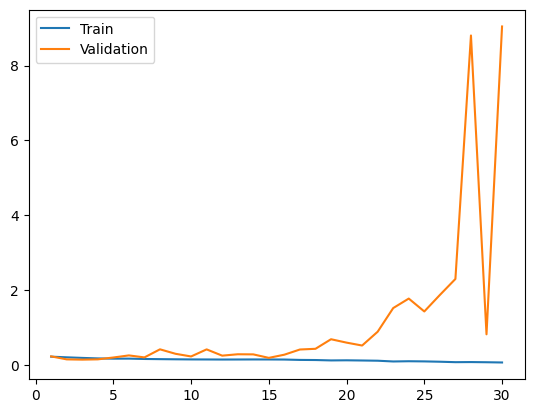

In [21]:
plt.plot(history_ft2["epoch"], history_ft2["train_loss"], label="Train")
plt.plot(history_ft2["epoch"], history_ft2["val_loss"], label="Validation")
plt.legend()

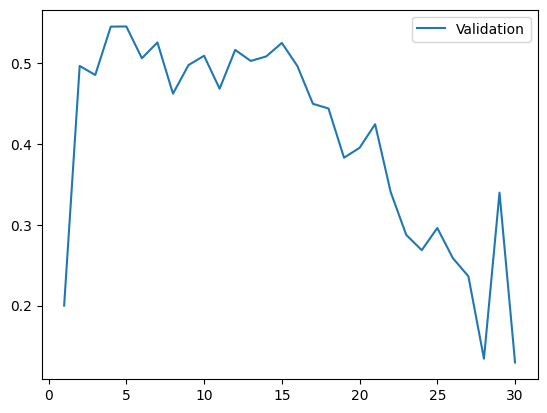

In [22]:
plt.plot(history_ft2["epoch"], history_ft2["val_ccc"], label="Validation")
plt.legend()

Treinando com a resnet congelada durante todo o treinamento e aumentando o número de epocas:

In [23]:
EPOCHS = 100

model_rn_mel_ft3 = ResNet18_Mel(
    dropout_p=0.3
).to(device)

criterion = nn.MSELoss()
optimizer = AdamW(model_rn_mel_ft3.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5, verbose=True)

print(f"Parâmetros treináveis: {sum(p.numel() for p in model_rn_mel_ft3.parameters() if p.requires_grad):,}")

history_ft3 = train_model_fine_tuning_audio(
    model=model_rn_mel_ft3,
    train_loader=train_mel_loader_balanced,
    val_loader=valid_mel_loader_balanced,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    epochs=EPOCHS,
    device=device,
    patience=EPOCHS,
    checkpoint_path="/mnt/storage_C4/gaussian_football/models/checkpoints/resnet18_audio_finetuning_resnet_congelada.pth",
    unfreeze_epoch=EPOCHS,
    nome_modelo='RESNET_AUDIO_3A_TENTATIVA_FINETUNING'
)

/mnt/storage_C4/gaussian_football/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Parâmetros treináveis: 11,318,081
TensorBoard: runs/arousal_RESNET_AUDIO_3A_TENTATIVA_FINETUNING_20260612-131141
=> Configuração Inicial: Congelando os pesos da ResNet (exceto a primeira camada)...


Época 1/100 [val]: 100%|██████████| 290/290 [00:00<00:00, 292.22it/s]


Época [1/100] [Congelada] | Train Loss: 0.2157 | Val Loss: 0.1707 | Val MAE: 0.3641 | Val CCC: 0.2527 | LR: 1.00e-04
Novo melhor modelo salvo! (CCC: 0.2527)


Época 2/100 [val]: 100%|██████████| 290/290 [00:00<00:00, 552.28it/s]


...

Época [98/100] [Congelada] | Train Loss: 0.1387 | Val Loss: 0.3144 | Val MAE: 0.4137 | Val CCC: 0.4807 | LR: 1.22e-08
Sem melhora por 93/100 épocas.


Época 99/100 [val]: 100%|██████████| 290/290 [00:00<00:00, 549.78it/s]


Época [99/100] [Congelada] | Train Loss: 0.1394 | Val Loss: 0.3570 | Val MAE: 0.4300 | Val CCC: 0.4679 | LR: 1.22e-08
Sem melhora por 94/100 épocas.


Época 100/100 [val]: 100%|██████████| 290/290 [00:00<00:00, 543.91it/s]


Época [100/100] [Congelada] | Train Loss: 0.1478 | Val Loss: 0.4653 | Val MAE: 0.4775 | Val CCC: 0.4446 | LR: 1.22e-08
Sem melhora por 95/100 épocas.

Treinamento concluído. Melhor CCC: 0.5229


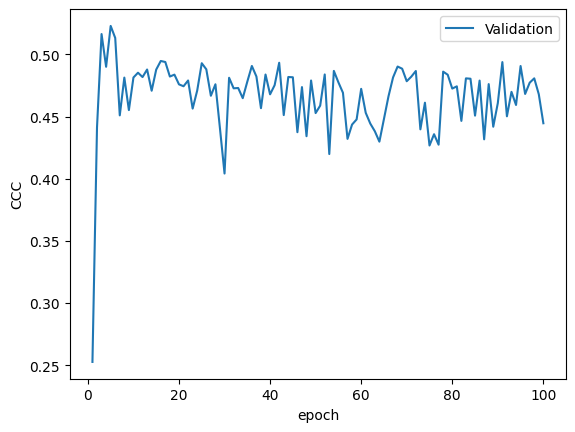

In [24]:
plt.plot(history_ft3["epoch"], history_ft3["val_ccc"], label="Validation")
plt.xlabel('epoch')
plt.ylabel('CCC')
plt.legend()

## Treinar RESNET18 mudando o num_layers